### Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler, MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from imblearn.over_sampling import BorderlineSMOTE
from imblearn.under_sampling import RandomUnderSampler, NearMiss
from imblearn.combine import SMOTETomek
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report, f1_score, precision_score, recall_score
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter
from scipy import stats
import shap
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

/opt/anaconda3/envs/sklearn-env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load the Data and Preprocessing Data

In [ ]:
# Load the uploaded label file
df = pd.read_csv("gz2_hart16.csv")

# Show structure of labels
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 239695 entries, 0 to 239694
Columns: 231 entries, dr7objid to t11_arms_number_a37_cant_tell_flag
dtypes: float64(150), int64(77), str(4)
memory usage: 430.0 MB


In [3]:
df.head()

,dr7objid,ra,dec,rastring,decstring,sample,gz2_class,total_classifications,total_votes,t01_smooth_or_features_a01_smooth_count,...,t11_arms_number_a36_more_than_4_fraction,t11_arms_number_a36_more_than_4_weighted_fraction,t11_arms_number_a36_more_than_4_debiased,t11_arms_number_a36_more_than_4_flag,t11_arms_number_a37_cant_tell_count,t11_arms_number_a37_cant_tell_weight,t11_arms_number_a37_cant_tell_fraction,t11_arms_number_a37_cant_tell_weighted_fraction,t11_arms_number_a37_cant_tell_debiased,t11_arms_number_a37_cant_tell_flag
0,587732591714893851,179.042984,60.522518,11:56:10.32,+60:31:21.1,original,Sc+t,45,342,0,...,0.450,0.450,0.482646,0,16,16.0,0.400,0.400,0.394506,0
1,588009368545984617,135.084396,52.494240,09:00:20.26,+52:29:39.3,original,Sb+t,42,332,1,...,0.512,0.503,0.504833,0,13,13.0,0.317,0.323,0.322743,0
2,587732484359913515,183.371979,50.741508,12:13:29.27,+50:44:29.4,original,Ei,36,125,28,...,0.000,0.000,0.000000,0,0,0.0,0.000,0.000,0.000000,0
3,587741723357282317,186.251953,28.558598,12:25:00.47,+28:33:31.0,original,Sc+t,28,218,1,...,0.240,0.240,0.241322,0,6,6.0,0.240,0.240,0.239765,0
4,587738410866966577,161.086395,14.084465,10:44:20.73,+14:05:04.1,original,Er,43,151,33,...,0.000,0.000,0.000000,0,0,0.0,0.000,0.000,0.000000,0


In [ ]:
drop_cols = [c for c in df.columns if
             ('_count' in c) or
             ('_weight' in c) or
             ('_flag' in c) or
             ('_fraction' in c and 'debiased' not in c)]

drop_cols += ['dr7objid','ra','dec','rastring','decstring','sample','gz2_class']

df_clean = df.drop(columns=drop_cols)

Dataset shape awal: (239695, 231)
             dr7objid          ra        dec     rastring    decstring  \
0  587732591714893851  179.042984  60.522518  11:56:10.32  +60:31:21.1   
1  588009368545984617  135.084396  52.494240  09:00:20.26  +52:29:39.3   
2  587732484359913515  183.371979  50.741508  12:13:29.27  +50:44:29.4   
3  587741723357282317  186.251953  28.558598  12:25:00.47  +28:33:31.0   
4  587738410866966577  161.086395  14.084465  10:44:20.73  +14:05:04.1   

     sample gz2_class  total_classifications  total_votes  \
0  original      Sc+t                     45          342   
1  original      Sb+t                     42          332   
2  original        Ei                     36          125   
3  original      Sc+t                     28          218   
4  original        Er                     43          151   

   t01_smooth_or_features_a01_smooth_count  ...  \
0                                        0  ...   
1                                        1  ...   
2

In [12]:
smooth = df_clean["t01_smooth_or_features_a01_smooth_debiased"]
disk   = df_clean["t01_smooth_or_features_a02_features_or_disk_debiased"]
spiral = df_clean["t04_spiral_a08_spiral_debiased"]

conditions = [
    (smooth > 0.6),                         # Non-spiral
    (disk > 0.5) & (spiral > 0.5)           # Spiral
]

choices = [1, 2]

df_clean["target"] = np.select(conditions, choices, default=0)

In [ ]:
df_clean.dropna(inplace=True)

In [ ]:
X = df_clean.drop(columns=["target"])
y = df_clean["target"]


# Normalization

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Combine back with target
df_final = X_scaled.copy()
df_final["target"] = y.values
df_final

,total_classifications,total_votes,t01_smooth_or_features_a01_smooth_debiased,t01_smooth_or_features_a02_features_or_disk_debiased,t01_smooth_or_features_a03_star_or_artifact_debiased,t02_edgeon_a04_yes_debiased,t02_edgeon_a05_no_debiased,t03_bar_a06_bar_debiased,t03_bar_a07_no_bar_debiased,t04_spiral_a08_spiral_debiased,...,t10_arms_winding_a28_tight_debiased,t10_arms_winding_a29_medium_debiased,t10_arms_winding_a30_loose_debiased,t11_arms_number_a31_1_debiased,t11_arms_number_a32_2_debiased,t11_arms_number_a33_3_debiased,t11_arms_number_a34_4_debiased,t11_arms_number_a36_more_than_4_debiased,t11_arms_number_a37_cant_tell_debiased,target
0,0.460317,0.543554,0.000,0.988,0.014252,0.047681,0.953848,0.025,0.975305,1.000000,...,0.676487,0.301320,0.025,0.0,0.075071,0.024617,0.049583,0.482646,0.394506,2
1,0.412698,0.526132,0.024,0.976,0.000000,0.000000,1.000000,0.080,0.920038,1.000000,...,0.871056,0.080068,0.050,0.0,0.098063,0.049983,0.024977,0.504833,0.322743,2
2,0.317460,0.165505,0.780,0.139,0.096200,0.000000,1.000000,0.400,0.600190,0.000000,...,0.000000,0.000000,0.000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,1
3,0.190476,0.327526,0.036,0.964,0.000000,0.036974,0.963112,0.038,0.962028,0.962366,...,0.640306,0.319844,0.040,0.0,0.079018,0.240087,0.200076,0.241322,0.239765,2
4,0.428571,0.210801,0.767,0.186,0.055819,0.125182,0.878825,0.000,1.000000,0.000000,...,0.000000,0.000000,0.000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239384,0.412698,0.182927,0.823,0.174,0.003563,0.857000,0.143000,0.000,1.000000,0.000000,...,0.000000,0.000000,0.000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,1
239385,0.476190,0.271777,0.541,0.263,0.233967,0.000000,1.000000,0.000,1.000000,0.000000,...,0.000000,0.000000,0.000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0
239386,0.507937,0.233449,0.789,0.156,0.065321,0.000000,1.000000,0.143,0.857000,0.286000,...,0.500000,0.500000,0.000,0.0,0.000000,0.000000,0.000000,0.000000,1.000000,1
239387,0.507937,0.303136,0.531,0.278,0.226841,0.000000,1.000000,0.000,1.000000,0.076000,...,1.000000,0.000000,0.000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0


### Feature Analysis

In [ ]:
# Preparation data using df_final
# Split features and target from df_final
X = df_final.drop('target_class', axis=1)
y = df_final['target_class']

print("=" * 60)
print("Data before Resampling")
print("=" * 60)
print(f"Shape X: {X.shape}")
print(f"Shape y: {y.shape}")
print("\nClass distribution before Resampling:")
print(y.value_counts().sort_index())
for cls in sorted(y.unique()):
    count = (y == cls).sum()
    print(f"  Class {cls}: {count} samples ({count/len(y)*100:.2f}%)")

# Calculate class weights from original distribution
classes = np.unique(y)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y
)
class_weight_dict = dict(zip(classes, class_weights))

print("\n" + "=" * 60)
print("Class Weights")
print("=" * 60)
for cls, weight in class_weight_dict.items():
    print(f"  Class {cls}: {weight:.4f}")

# Resampling with undersampling or oversampling, choose one 

# Undersampling
nearmiss = NearMiss(
   version=1,  
    n_neighbors=3
)
# Oversampling
# smote_tomek = SMOTETomek()

# X_resampled, y_resampled = smote_tomek.fit_resample(X, y)
X_resampled, y_resampled = nearmiss.fit_resample(X, y)

print("\n" + "=" * 60)
print("Data after Resampling")
print("=" * 60)
print(f"Shape X_resampled: {X_resampled.shape}")
print(f"Shape y_resampled: {y_resampled.shape}")
print("\nClass distribution after Resampling:")
unique, counts = np.unique(y_resampled, return_counts=True)
for cls, count in zip(unique, counts):
    print(f"  Class {cls}: {count} samples ({count/len(y_resampled)*100:.2f}%)")

# Convert to DataFrame for easier LDA later
X_resampled_df = pd.DataFrame(X_resampled, columns=X.columns)
y_resampled_series = pd.Series(y_resampled, name='target_class')

Data sebelum SMOTETomek
Shape X: (239389, 39)
Shape y: (239389,)

Distribusi kelas sebelum SMOTETomek:
target
0    55603
1    86169
2    97617
Name: count, dtype: int64
  Kelas 0: 55603 sampel (23.23%)
  Kelas 1: 86169 sampel (36.00%)
  Kelas 2: 97617 sampel (40.78%)

Class Weights
  Kelas 0: 1.4351
  Kelas 1: 0.9260
  Kelas 2: 0.8174

Data setelah SMOTETomek
Shape X_resampled: (290125, 39)
Shape y_resampled: (290125,)

Distribusi kelas setelah SMOTETomek:
  Kelas 0: 96589 sampel (33.29%)
  Kelas 1: 96634 sampel (33.31%)
  Kelas 2: 96902 sampel (33.40%)


In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=209,
    class_weight="balanced"
)
# Split 7-1-2
X_temp, X_test, y_temp, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=209, stratify=y_resampled
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, random_state=209, stratify=y_temp
)

rf.fit(X_train, y_train)
importance = rf.feature_importances_

In [17]:
rf_importance = pd.Series(
    rf.feature_importances_,
    index=X_test.columns
).sort_values(ascending=False)

print("Top RF Feature Importance")
print(rf_importance.head(10))

Top RF Feature Importance
t01_smooth_or_features_a01_smooth_debiased              0.375060
t01_smooth_or_features_a02_features_or_disk_debiased    0.171366
t04_spiral_a08_spiral_debiased                          0.113571
t04_spiral_a09_no_spiral_debiased                       0.073074
t11_arms_number_a32_2_debiased                          0.036787
t10_arms_winding_a29_medium_debiased                    0.036685
t10_arms_winding_a28_tight_debiased                     0.033246
t11_arms_number_a37_cant_tell_debiased                  0.021675
total_votes                                             0.017428
t10_arms_winding_a30_loose_debiased                     0.016902
dtype: float64


In [18]:
result = permutation_importance(rf, X_test, y_test)
importance = result.importances_mean
perm_importance = pd.Series(
    importance,
    index=X_test.columns
).sort_values(ascending=False)

print("\nTop Permutation Importance")
print(perm_importance.head(10))


Top Permutation Importance
t01_smooth_or_features_a01_smooth_debiased              0.443157
t04_spiral_a08_spiral_debiased                          0.274730
t01_smooth_or_features_a02_features_or_disk_debiased    0.163771
t04_spiral_a09_no_spiral_debiased                       0.000041
t03_bar_a06_bar_debiased                                0.000021
t10_arms_winding_a28_tight_debiased                     0.000017
total_classifications                                   0.000014
t05_bulge_prominence_a11_just_noticeable_debiased       0.000014
total_votes                                             0.000014
t07_rounded_a16_completely_round_debiased               0.000014
dtype: float64


                                                    RF_Importance  \
t01_smooth_or_features_a01_smooth_debiased               0.375060   
t04_spiral_a08_spiral_debiased                           0.113571   
t01_smooth_or_features_a02_features_or_disk_deb...       0.171366   
t04_spiral_a09_no_spiral_debiased                        0.073074   
t03_bar_a06_bar_debiased                                 0.007911   
t10_arms_winding_a28_tight_debiased                      0.033246   
t05_bulge_prominence_a11_just_noticeable_debiased        0.008850   
total_classifications                                    0.003330   
t07_rounded_a16_completely_round_debiased                0.002924   
t05_bulge_prominence_a12_obvious_debiased                0.003209   
total_votes                                              0.017428   
t11_arms_number_a37_cant_tell_debiased                   0.021675   
t10_arms_winding_a29_medium_debiased                     0.036685   
t05_bulge_prominence_a13_dominant_

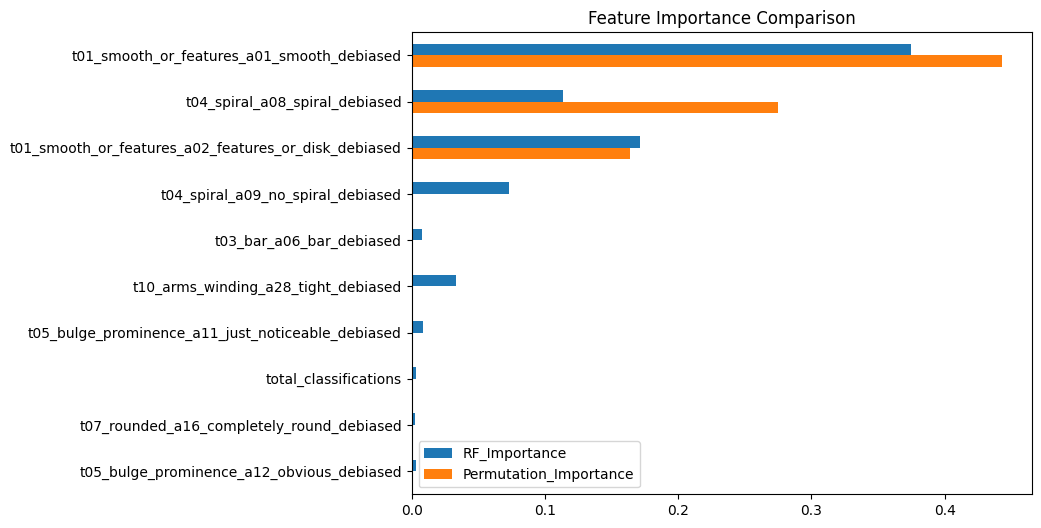

In [20]:
importance_df = pd.DataFrame({
    "RF_Importance": rf_importance,
    "Permutation_Importance": perm_importance
})

importance_df = importance_df.sort_values(
    by="Permutation_Importance",
    ascending=False
)

print(importance_df.head(20))

importance_df.head(10).plot(kind="barh", figsize=(8,6))
plt.gca().invert_yaxis()
plt.title("Feature Importance Comparison")
plt.show()

In [30]:
explainer = shap.TreeExplainer(rf)
X_sample = X_test.sample(300, random_state=209)

shap_values = explainer.shap_values(X_sample)

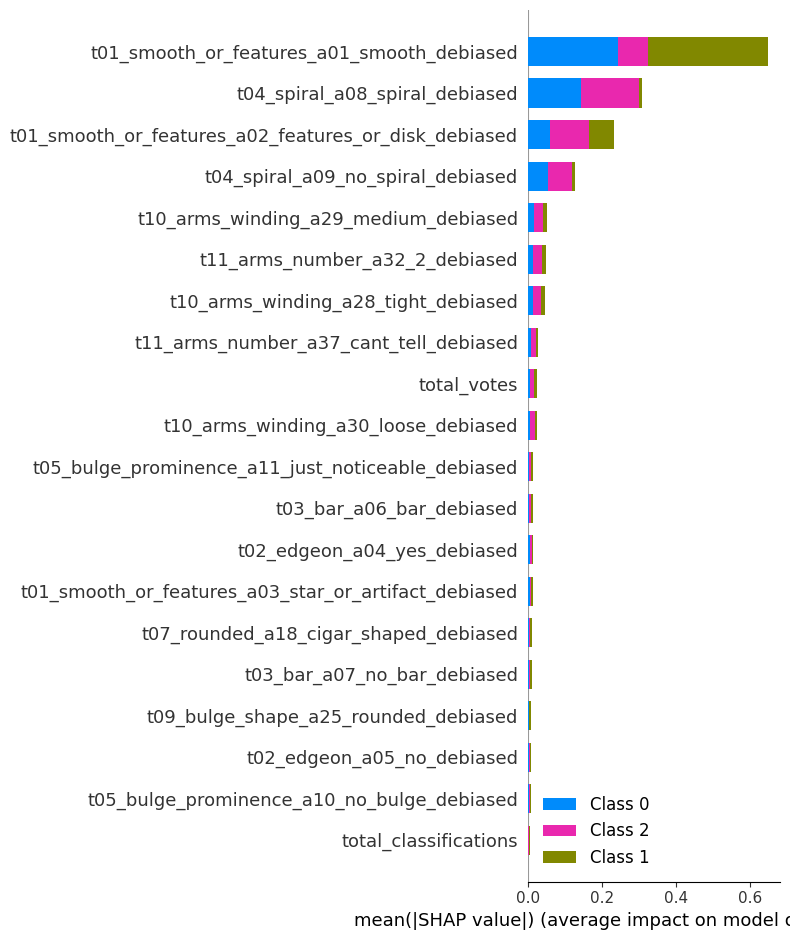

In [33]:
shap.summary_plot(shap_values, X_sample, plot_type="bar")

In [34]:
feature_names = X_sample.columns
class_names = ['Uncertain','Elliptical','Spiral']

shap_importance = {}

for i, class_name in enumerate(class_names):

    vals = np.abs(shap_values[:,:,i]).mean(axis=0)

    shap_importance[class_name] = vals

df_shap = pd.DataFrame(shap_importance, index=feature_names)

print(df_shap)

                                                    Uncertain  Elliptical  \
total_classifications                                0.001072    0.002453   
total_votes                                          0.004968    0.008571   
t01_smooth_or_features_a01_smooth_debiased           0.242569    0.324075   
t01_smooth_or_features_a02_features_or_disk_deb...   0.060747    0.067149   
t01_smooth_or_features_a03_star_or_artifact_deb...   0.006153    0.004485   
t02_edgeon_a04_yes_debiased                          0.006532    0.003383   
t02_edgeon_a05_no_debiased                           0.003779    0.001883   
t03_bar_a06_bar_debiased                             0.002838    0.004297   
t03_bar_a07_no_bar_debiased                          0.003009    0.002938   
t04_spiral_a08_spiral_debiased                       0.144419    0.010429   
t04_spiral_a09_no_spiral_debiased                    0.054536    0.009335   
t05_bulge_prominence_a10_no_bulge_debiased           0.003216    0.003593   